In [427]:
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import torch.nn as nn
import torch.optim
from sklearn.metrics import mean_squared_error

In [428]:
df = pd.read_excel('data/input.xlsx')

In [429]:
df['годы'] = pd.to_numeric(df['годы'], errors='coerce')
df['flag_ussr_collapse'] = df['годы'].apply(lambda x: 1 if x == 1991 else 0)
df['flag_crisis_2008'] = df['годы'].apply(lambda x: 1 if x in [2008, 2009] else 0)
df['flag_covid'] = df['годы'].apply(lambda x: 1 if x in [2020, 2021] else 0)

In [430]:
import numpy as np
import pandas as pd

# Данные о ВВП по годам
years_vvp = np.array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                      2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

vvp_values = np.array([1428.5, 2007.8, 2342.5, 2629.6, 4823.2, 7305.6, 8943.6, 10830.5, 13208.2, 17027.2,
                       21609.8, 26917.2, 33247.5, 41276.8, 38807.2, 46308.5, 60114.0, 68103.4, 72985.7,
                       79030.0, 83087.4, 85616.1, 91843.2, 103861.7, 109608.3, 107658.1, 134727.5,
                       156940.9, 176413.6])  # 201152.1

# Подставим данные ВВП для существующих годов
df['vvp'] = np.interp(df['годы'], years_vvp, vvp_values)

# 1991-1999 - Положительные значения (кризисные годы)
# 2000-2007 - Отрицательные значения (рост экономики и стабилизация)
# 2008-2015 - Положительные значения (кризисы, санкции)
# 2020 - Положительное значение (пандемия)
years = [
    1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,  # 1991-1999
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,  # 2000-2007
    2009, 2010, 2011, 2012, 2013, 2014, 2015,  # 2008-2015
    2020  # 2020
]

crisis = [
    10, 10, 10, 15, 20, 10, 10, 10, 30,  # 1991-1999
    0, 0, -5, -10, -15, 0, -5, -5, -10,  # 2000-2007
    25, 10, 0, -5, -5,  # 2008-2015
    15  # 2020
]

# Добавим столбец кризиса в DataFrame df
df['crisis'] = df['годы'].map(dict(zip(years, crisis))).fillna(0)

# Массив коэффициентов войн и соответствующие годы
war = [
    0, 0, 0, 5, 10,  # 1991-1995 (локальные конфликты, перемирие)
    10, 15, 20, 15, 0,  # 1996-2000 (вторая чеченская война)
    25, 30, 20, 15, 10,  # 2001-2005 (миротворческие операции)
    10, 10, 5, 0, 0,  # 2006-2010 (участие в Сирии, другие конфликты)
    20, 30, 40, 40,  # 2011-2015 (активные операции в Сирии и на Украине)
    50  # 2020 (конфликт на Украине)
]

# Добавим столбец кризиса в DataFrame df
df['war'] = df['годы'].map(dict(zip(years, war))).fillna(0)
df



,годы,Всего браков,М до 18,М 18-24,М 25-34,М 35 и более,М не указан,Ж до 18,Ж 18-24,Ж 25-34,Ж 35 и более,Ж не указан,flag_ussr_collapse,flag_crisis_2008,flag_covid,vvp,crisis,war
0,1960,1499581,226,798207,468734,232012,402,5015,949816,320916,223208,626,0,0,0,1428.5,0.0,0.0
1,1970,1319227,2464,809466,328416,178797,84,19227,933308,201485,165041,166,0,0,0,1428.5,0.0,0.0
2,1980,1464579,5115,902610,369768,187027,59,32591,1000767,272157,158944,120,0,0,0,1428.5,0.0,0.0
3,1990,1319928,13536,692941,389739,223628,84,72073,779437,273108,195227,83,0,0,0,1428.5,0.0,0.0
4,1991,1277232,13506,671857,367477,224314,78,81035,746538,253344,196240,75,1,0,0,1428.5,10.0,0.0
5,1992,1053717,10611,561052,288860,193113,81,72697,615119,197645,168177,79,0,0,0,1428.5,10.0,0.0
6,1993,1106723,9837,605349,295350,196116,71,75936,660105,200753,169863,66,0,0,0,1428.5,10.0,0.0
7,1994,1080600,8844,578305,293623,199774,54,69237,638631,200070,172605,57,0,0,0,1428.5,15.0,5.0
8,1995,1075219,8044,555859,303953,207319,44,63633,628329,205549,177655,53,0,0,0,1428.5,20.0,10.0
9,1996,866651,6167,430853,254362,175246,23,47481,500163,170058,148921,28,0,0,0,2007.8,10.0,10.0


In [431]:
# Функция для получения фичей по case_number
def get_features(df, case_number):
    match case_number:
        case 0:
            return df[['годы', 'vvp']].values
        case 1:
            return df[['годы', 'crisis', 'war']].values
        case 2:
            return df[['годы', 'vvp', 'crisis', 'war']].values
        case _:
            raise ValueError(f"Invalid case number: {case_number}")

In [432]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch


def prepare_data(df, case_number, test_size=0.06):
    x_raw = get_features(df, case_number)  # сохраняем необработанный X
    y = df['М 25-34'].values.reshape(-1, 1)

    # Нормализация данных
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    x = scaler_x.fit_transform(x_raw)
    y = scaler_y.fit_transform(y)

    # Разделение данных на тренировочную и тестовую выборки
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, shuffle=False, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Переводим в тензоры
    x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    x_test = torch.tensor(x_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    return x_train, y_train, x_test, y_test, scaler_x, scaler_y, device, x_raw


In [433]:
# Функция обучения модели
def train(model, x, y, num_epochs=80
          , lr=0.005):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')
    return model

In [434]:
# Функция построения модели
class NetActivate(nn.Module):
    def __init__(self, input_dim):
        super(NetActivate, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def forward(self, x):
        return self.model(x)

In [435]:
def generate_years(start_year, num_years, case_number, df_vvp, df_coeffs):
    years = np.array([start_year + i for i in range(1, num_years + 1)])
    years_df = pd.DataFrame({'year': years})

    # Определяем нужные признаки по case_number
    match case_number:
        case 0:
            cols = ['vvp']
        case 1:
            cols = ['crisis', 'war']
        case 2:
            cols = ['vvp', 'crisis', 'war']
        case _:
            raise ValueError(f"Invalid case number: {case_number}")

    # Объединяем по годам с df_coeffs и df_vvp
    merged = years_df.merge(df_coeffs, on='year', how='left').merge(df_vvp, on='year', how='left')
    merged.fillna(0, inplace=True)

    return merged[['year'] + cols].to_numpy()


In [436]:
def plot_results(model, x, y, x_raw=None, new_years=None, show_history=True):
    model.eval()
    with torch.no_grad():
        x_plot = x
        y_true = y
        y_pred = model(x_plot)

    x_original = scaler_x.inverse_transform(x_plot.cpu().numpy())
    y_true_original = scaler_y.inverse_transform(y_true.cpu().numpy())
    y_pred_original = scaler_y.inverse_transform(y_pred.cpu().numpy())

    n = x_test.shape[0]
    x_last_true = x_original[-n:]
    y_last_true = y_true_original[-n:]
    y_last_pred = y_pred_original[-n:]

    # rmse = np.sqrt(mean_squared_error(y_last_true, y_last_pred))

    if new_years is not None:
        new_years_normalized = scaler_x.transform(new_years)
        new_predictions = model(torch.tensor(new_years_normalized, dtype=torch.float32).to(device))
        new_predictions_original = scaler_y.inverse_transform(new_predictions.detach().cpu().numpy())

        x_pred_original = np.vstack([x_original, new_years])
        y_pred_original = np.vstack([y_pred_original, new_predictions_original])
    else:
        x_pred_original = x_original
        y_pred_original = y_pred_original

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # --- Первый график ---
    axs[0].plot(x_original[:, 0], y_true_original, label='True')
    axs[0].plot(x_pred_original[:, 0], y_pred_original, label='Pred')
    axs[0].axvline(x=x_original[:, 0].max(), color='r', linestyle='--',
                   label=f"Текущий год: {int(x_original[:, 0].max())}")
    axs[0].set_xlabel('Год')
    axs[0].set_ylabel('Количество браков - всего')
    axs[0].legend()
    axs[0].grid(True)
    axs[0].set_title(f"RMSE последних {n} лет (до новых предсказаний): {rmse:.0f}")

    for i in range(n):
        x_val = x_last_true[i][0]
        y_true_val = y_last_true[i].item()
        diff = y_true_val - y_last_pred[i].item()
        axs[0].text(x_val, y_true_val, f'{diff:.0f}', color='green', fontsize=9, ha='left', va='bottom')

    # --- Второй график ---
    if new_years is not None and new_years.shape[1] > 1:
        years_new = new_years[:, 0]
        features_new = new_years[:, 1:]

        if show_history and x_raw is not None and x_raw.shape[0] > 0:
            years_old = x_raw[:, 0]
            features_old = x_raw[:, 1:]
            years = np.concatenate([years_old, years_new])
            features = np.concatenate([features_old, features_new])
        else:
            years = years_new
            features = features_new

        num_features = features.shape[1]
        has_gdp = num_features in (1, 3)
        has_coeffs = num_features >= 2

        gdp = features[:, 0] if has_gdp else None

        if has_coeffs:
            if num_features == 2:
                coeffs = features[:, 0:2]  # обе фичи — коэффициенты
            elif num_features == 3:
                coeffs = features[:, 1:3]  # после ВВП
            else:
                coeffs = features[:, 0:1]
        else:
            coeffs = None

        ax_gdp = axs[1]
        ax_coeff = axs[1].twinx() if coeffs is not None else axs[1]

        # График ВВП
        if gdp is not None:
            ax_gdp.plot(years, gdp, label='ВВП', color='purple')
            ax_gdp.set_ylabel('ВВП')
            ax_gdp.legend(loc='upper left')

        # График коэффициентов
        if coeffs is not None:
            labels = ['Кризисы в экономике', 'Военные действия']
            for i in range(coeffs.shape[1]):
                label = labels[i] if i < len(labels) else f'Коэффициент {i + 1}'
                ax_coeff.plot(years, coeffs[:, i], label=label, linestyle='--')

                for j, val in enumerate(coeffs[:, i]):
                    if abs(val) == np.max(np.abs(coeffs[:, i])):  # максимум по модулю
                        ax_coeff.text(years[j], val, f'{val:.0f}', color='blue', fontsize=9, ha='center', va='bottom')

            ax_coeff.set_ylabel('Коэффициенты (кризис, война и т.д.)')
            ax_coeff.legend(loc='upper right')

        axs[1].axvline(x=x_original[:, 0].max(), color='r', linestyle='--', label='Текущий год')
        axs[1].set_xlabel('Год')
        axs[1].grid(True)
        axs[1].set_title('ВВП и/или коэффициенты по годам')

    plt.tight_layout()
    plt.show()



In [437]:
def run_model(df, case_number):
    # Подготовка данных
    x_train, y_train, x_test, y_test, scaler_x, scaler_y, device, _ = prepare_data(df, case_number)
    torch.manual_seed(2)

    # Строим модель
    input_dim = x_train.shape[1]
    model = NetActivate(input_dim)

    # Обучаем модель
    model = train(model, x_train, y_train)

    # Получаем предсказания модели для тестовых данных
    model.eval()
    with torch.no_grad():
        predictions = model(x_test.to(device))

    predictions_original = scaler_y.inverse_transform(predictions.cpu().numpy())
    y_test_original = scaler_y.inverse_transform(y_test.cpu().numpy())

    # Последние n точек для расчета RMSE (или все)
    rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))

    return model, rmse


In [438]:
coef_df = pd.DataFrame({
    'year': [2024 + i for i in range(30)],

    'crisis': [
        1, 0, 0, 5, 10, -5, 0, 0, 0, -15,  # 2021-2030
        5, 0, 0, -10, -5, 15, 10, 0, -20, -10,  # 2031-2040
        10, -10, 0, 5, 0, -5, 0, 0, -10, 0  # 2041-2050
    ],

    'war': [
        0, 0, 0, 0, 10, 10, 5, 0, 0, 0,  # 2021-2030
        15, 25, 30, 40, 50, 30, 30, 25, 20, 0,  # 2031-2040
        10, 0, 5, 5, 0, 10, 0, 0, 20, 0  # 2041-2050
    ],
})

new_vvp_df = pd.DataFrame({
    'year': [2024 + i for i in range(30)],
    'vvp': [
        224327, 227421, 233752, 242022, 248788, 247581, 247663, 251884, 258359, 264035,
        258035, 262487, 267309, 272331, 275804, 276658, 281774, 287160, 291241, 296758,
        301392, 305456, 311062, 315921, 319500, 322662, 326619, 329263, 334029, 336646],
})

In [439]:
# Функция для оптимизации с Optuna
def objective(trial):
    # Выбираем случайный вариант case_number с помощью Optuna
    case_number = trial.suggest_int("case_number", 0, 2)
    # Вызываем обычную версию модели
    model, rmse = run_model(df, case_number)

    return rmse


# Запуск поиска лучшего case_number с помощью Optuna
torch.manual_seed(2)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)  # количество попыток

# Вывод лучших результатов
print(f"Best trial: {study.best_trial.number}")
print(f"Best RMSE: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

# Теперь обучаем модель на лучших параметрах
best_case_number = study.best_params['case_number']

[I 2025-05-04 01:57:51,700] A new study created in memory with name: no-name-65534d1e-8165-4ec7-8c70-cedeb49a7d43


Epoch [10/80], Loss: 0.1028
Epoch [20/80], Loss: 0.0658
Epoch [30/80], Loss: 0.0481
Epoch [40/80], Loss: 0.0346


[I 2025-05-04 01:57:52,209] Trial 0 finished with value: 107459.58779001527 and parameters: {'case_number': 1}. Best is trial 0 with value: 107459.58779001527.


Epoch [50/80], Loss: 0.0260
Epoch [60/80], Loss: 0.0199
Epoch [70/80], Loss: 0.0152
Epoch [80/80], Loss: 0.0113
Epoch [10/80], Loss: 0.1028
Epoch [20/80], Loss: 0.0658
Epoch [30/80], Loss: 0.0481
Epoch [40/80], Loss: 0.0346


[I 2025-05-04 01:57:52,669] Trial 1 finished with value: 107459.58779001527 and parameters: {'case_number': 1}. Best is trial 0 with value: 107459.58779001527.


...

Epoch [60/80], Loss: 0.0199
Epoch [70/80], Loss: 0.0152
Epoch [80/80], Loss: 0.0113
Epoch [10/80], Loss: 0.1028
Epoch [20/80], Loss: 0.0658
Epoch [30/80], Loss: 0.0481
Epoch [40/80], Loss: 0.0346
Epoch [50/80], Loss: 0.0260
Epoch [60/80], Loss: 0.0199


[I 2025-05-04 01:57:55,871] Trial 8 finished with value: 107459.58779001527 and parameters: {'case_number': 1}. Best is trial 5 with value: 44903.997862105774.


Epoch [70/80], Loss: 0.0152
Epoch [80/80], Loss: 0.0113
Epoch [10/80], Loss: 0.1028
Epoch [20/80], Loss: 0.0658
Epoch [30/80], Loss: 0.0481
Epoch [40/80], Loss: 0.0346
Epoch [50/80], Loss: 0.0260
Epoch [60/80], Loss: 0.0199


[I 2025-05-04 01:57:56,386] Trial 9 finished with value: 107459.58779001527 and parameters: {'case_number': 1}. Best is trial 5 with value: 44903.997862105774.


Epoch [70/80], Loss: 0.0152
Epoch [80/80], Loss: 0.0113
Best trial: 5
Best RMSE: 44903.997862105774
Best params: {'case_number': 2}


In [440]:
# best_case_number = 2
# Запускаем обучение модели с лучшими параметрами
model, rmse = run_model(df, best_case_number)

Epoch [10/80], Loss: 0.0807
Epoch [20/80], Loss: 0.0451
Epoch [30/80], Loss: 0.0356
Epoch [40/80], Loss: 0.0261
Epoch [50/80], Loss: 0.0187
Epoch [60/80], Loss: 0.0134
Epoch [70/80], Loss: 0.0093
Epoch [80/80], Loss: 0.0083


In [441]:
rmse

44903.997862105774

In [442]:
best_case_number

2

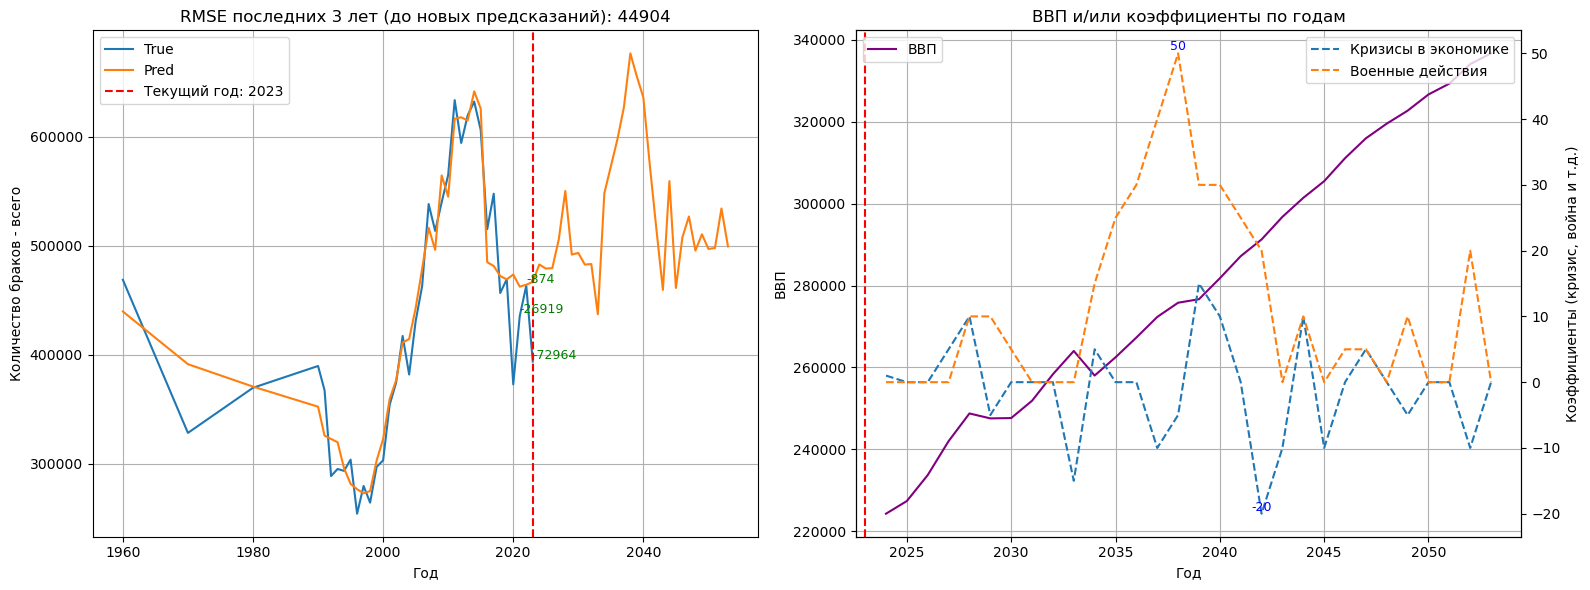

In [443]:
new_years = generate_years(int(df['годы'].max()), 30, best_case_number, new_vvp_df, coef_df)
x_train, y_train, x_test, y_test, scaler_x, scaler_y, device, x_raw = prepare_data(df, best_case_number)

x_all = torch.cat([x_train, x_test], dim=0)
y_all = torch.cat([y_train, y_test], dim=0)

plot_results(model, x_all, y_all, x_raw, new_years, show_history=False)